### Adaptive-step Taylor method 4th-order

Taylor method up to 4th-order + step-adaptive logic based on asyntotic expansion of the error. Let's solve the Hermite ODE:

\begin{cases}
    y'(x) = v(x) \\
    v'(x) = 2 \, x \, v(x) - 2 \, m \, y(x)
\end{cases}

Where $m$ is a natural number. The derivation of the system is available in *PDF* folder

In [1]:
import numpy as np
from scipy.special import hermite # Hermite polynomials from SciPy
from scipy.interpolate import make_interp_spline # Spline quadrature from SciPy
import matplotlib.pyplot as plt

In [2]:
def step(m, h, xn, yn, vn): # Computes a single step

    xn2 = xn * xn
    xn3 = xn2 * xn
    xn4 = xn3 * xn
    xn5 = xn4 * xn

    m2 = m * m
    m3 = m2 * m

    h2 = h * h
    h3 = h2 * h
    h4 = h3 * h
    h5 = h4 * h

    # y_{n + 1}
    yn1_term1 = h * vn
    yn1_term2 = h2 * (xn * vn - m * yn)
    yn1_term3 = (h3 / 3.0) * ((2.0 * xn2 + 1.0 - m) * vn - 2.0 * xn * m * yn)
    yn1_term4 = (h4 / 6.0) * (m2 * yn - 2.0 * xn2 * m * yn - 2.0 * m * yn - 2.0 * xn * m * vn + 2.0 * xn3 * vn + 3.0 * xn * vn)
    yn1_term5 = (h5 / 30.0) * (4.0 * xn * m2 * yn + m2 * vn - 4.0 * xn3 * m * yn - 10.0 * xn * m * yn - 6.0 * xn2 * m * vn - 4.0 *m * vn + 4.0 * xn4 * vn + 12.0 * xn2 * vn + 3.0 * vn)

    yn1_step4 = np.sum([yn, yn1_term1, yn1_term2, yn1_term3, yn1_term4])
    err_yn1 = np.abs(yn1_term5) # y_{n + 1} error

    # v_{n + 1}
    vn1_term1 = 2.0 * h * (xn * vn - m * yn)
    vn1_term2 = h2 * (- 2.0 * xn * m * yn - m * vn + 2.0 * xn2 * vn + vn)
    vn1_term3 = (2.0 * h3 / 3.0) * (m2 * yn - 2.0 * xn2 * m * yn - 2.0 * m * yn - 2.0 * xn * m * vn + 2.0 * xn3 * vn + 3.0 * xn * vn)
    vn1_term4 = (h4 / 6.0) * (4.0 * xn * m2 * yn + m2 * vn - 4.0 * xn3 * m * yn - 10.0 * xn * m * yn - 6.0 * xn2 * m * vn - 4.0 * m * vn + 4.0 * xn4 * vn + 12.0 * xn2 * vn + 3.0 * vn)
    vn1_term5 = (h5 / 15.0) * (xn * m2 * vn - m3 * yn + 6.0 * xn2 * m2 * yn + 6.0 * m2 * yn + 2.0 * xn * m2 * vn - 4.0 * xn4 * m * yn - 18.0 * xn2 * m * yn - 8.0 * m * yn - 8.0 * xn3 * m * vn - 15.0 * xn * m * vn + 4.0 * xn5 * vn + 20.0 * xn3 * vn + 15.0 * xn * vn)

    vn1_step4 = np.sum([vn, vn1_term1, vn1_term2, vn1_term3, vn1_term4])
    err_vn1 = np.abs(vn1_term5) # v_{n + 1} error

    return yn1_step4, err_yn1, vn1_step4, err_vn1 # Returns (y_{n + 1}, v_{n + 1}) and absolute errors

In [3]:
def scale_error(y, err_y, v, err_v, atol, rtol): # Compute the epsilon parameter

    threshold_y = atol + rtol * np.abs(y)
    threshold_v = atol + rtol * np.abs(v)

    err_y_scaled = err_y / threshold_y
    err_v_scaled = err_v / threshold_v

    eps = max(err_y_scaled, err_v_scaled)

    return eps

In [4]:
def new_h(eps, h_old, safety, max_growth): # Computes the new step size h_new
    
    eps = eps + 2.2e-16 # 2.2e-16 safeguard error divison

    factor = min(safety * eps ** (- 1 / 5), max_growth)
    h_new = h_old * factor

    return h_new

In [5]:
def taylor45(m, h0, x0, y0, v0, X, atol, rtol, safety, max_growth): # Fully step-adaptive solver
    
    # Initial setup
    h = h0
    x, y, v = x0, y0, v0
    x_list, y_list, v_list = [x0], [y0], [v0]

    while x < X:
        
        if x + h > X: h = X - x # Don't skip X

        y_new, err_y, v_new, err_v = step(m, h, x, y, v) # One step

        eps = scale_error(y_new, err_y, v_new, err_v, atol, rtol) # Computing epsilon
        if eps <= 1.0: # We accept y_new and v_new
            
            # Updates
            x += h
            y, v = y_new, v_new
            x_list.append(x); y_list.append(y); v_list.append(v)
            
            if x >= X: break

        h = new_h(eps, h, safety, max_growth) # Update h

    return np.array(x_list), np.array(y_list), np.array(v_list) # Returns x, y, v

Let's test it with $m = 12$

In [6]:
# Setup
m = 12
H = hermite(m) # Real solution
h0 = 1e-03 # Initial step size
x0, X = - 2.0, 2.0 # Range (-2, 2)

In [7]:
x, y, v = taylor45( # Solution
    m = m,
    h0 = h0,
    x0 = x0,
    y0 = H(x0),
    v0 = H.deriv()(x0),
    X = X,
    atol = 1e-12,
    rtol = 1e-09,
    safety = 0.8,
    max_growth = 1.5
    )

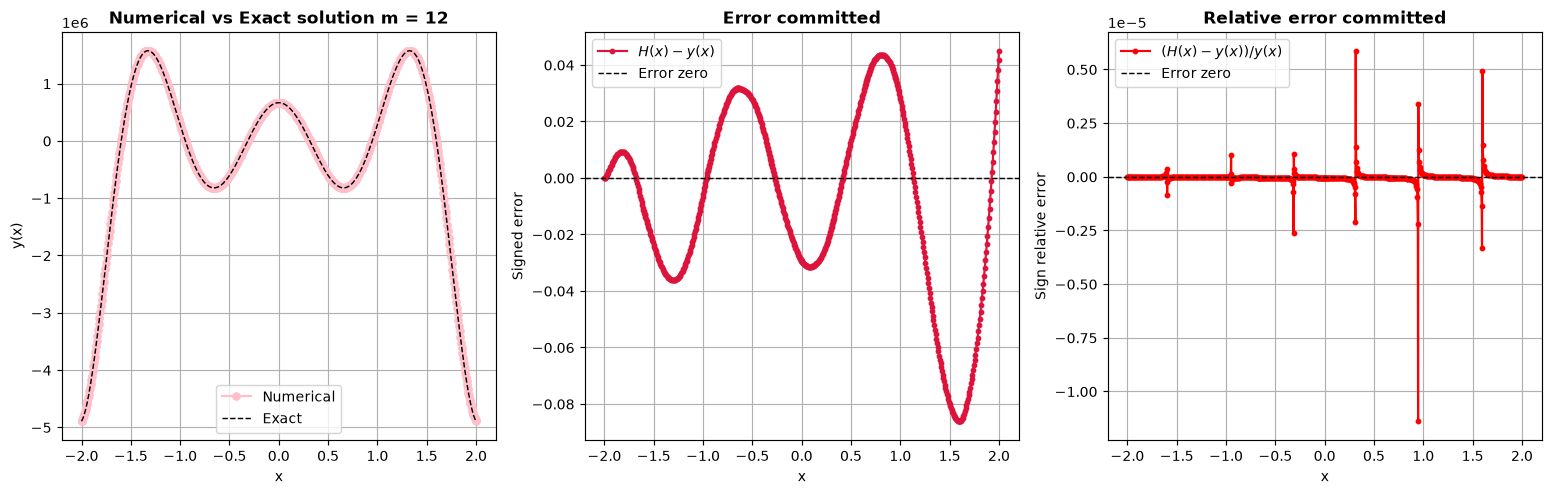

In [8]:
# Plotting results
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (15, 5))

ax1.plot(x, y, linestyle = 'solid', marker = 'o', label = 'Numerical', color = 'pink', markersize = 5)
ax1.plot(x, H(x), linestyle = 'dashed', label = 'Exact', color = 'black', linewidth = 1.0)
ax1.set_xlabel('x')
ax1.set_ylabel('y(x)')
ax1.set_title(f'Numerical vs Exact solution m = {m}', fontweight = 'bold')
ax1.legend(loc = 'best')
ax1.grid()

error = H(x) - y # Error with sign
ax2.plot(x[1:], error[1:], linestyle = 'solid', marker = 'o', color = 'crimson', label = r'$H(x) - y(x)$', markersize = 3)
ax2.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 1.0, label = 'Error zero')
ax2.set_xlabel('x')
ax2.set_ylabel('Signed error')
ax2.set_title('Error committed', fontweight = 'bold')
ax2.legend(loc = 'best')
ax2.grid()

rel_error = (H(x) - y) / y # Relative error
ax3.plot(x[1:], rel_error[1:], linestyle = 'solid', marker = 'o', color = 'red', label = r'$(H(x) - y(x)) / y(x)$', markersize = 3)
ax3.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 1.0, label = 'Error zero')
ax3.set_xlabel('x')
ax3.set_ylabel('Sign relative error')
ax3.set_title('Relative error committed', fontweight = 'bold')
ax3.legend(loc = 'best')
ax3.grid()

plt.tight_layout()
plt.show()

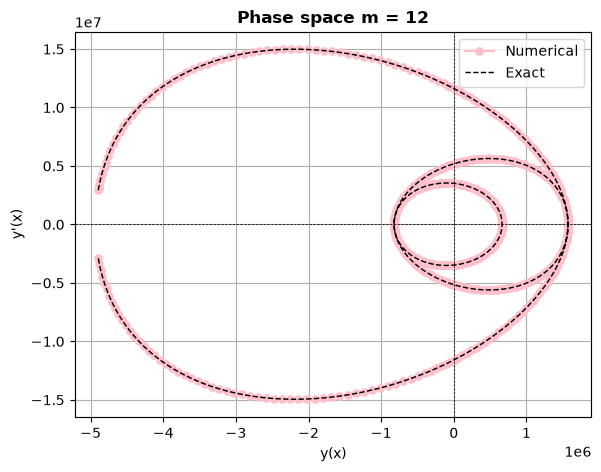

In [9]:
# Plotting phase space
plt.plot(y, v, linestyle = 'solid', marker = 'o', label = 'Numerical', color = 'pink', markersize = 5)
plt.plot(y, H.deriv()(x), linestyle = 'dashed', label = 'Exact', color = 'black', linewidth = 1.0)
plt.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 0.5)
plt.axvline(0, linestyle = 'dashed', color = 'black', linewidth = 0.5)
plt.xlabel('y(x)')
plt.ylabel("y'(x)")
plt.title(f'Phase space m = {m}', fontweight = 'bold')
plt.legend(loc = 'best')
plt.grid()
plt.show()

In [10]:
np.max(np.abs(H(x) - y)), np.max(np.abs((H(x) - y) / y)) # Maximum error committed, absolute and relative

(np.float64(0.08613869931650697), np.float64(1.1390211674366431e-05))

Let's retry for a smaller value of $m$, with higher tolerances

In [11]:
# Setup
m = 7
H = hermite(m) # Real solution
h0 = 0.1 # Initial step size
x0, X = - 2.0, 2.0 # Range (-2, 2)

In [12]:
x, y, v = taylor45( # Solution
    m = m,
    h0 = h0,
    x0 = x0,
    y0 = H(x0),
    v0 = H.deriv()(x0),
    X = X,
    atol = 1e-06,
    rtol = 1e-03,
    safety = 0.9,
    max_growth = 2.0
    )

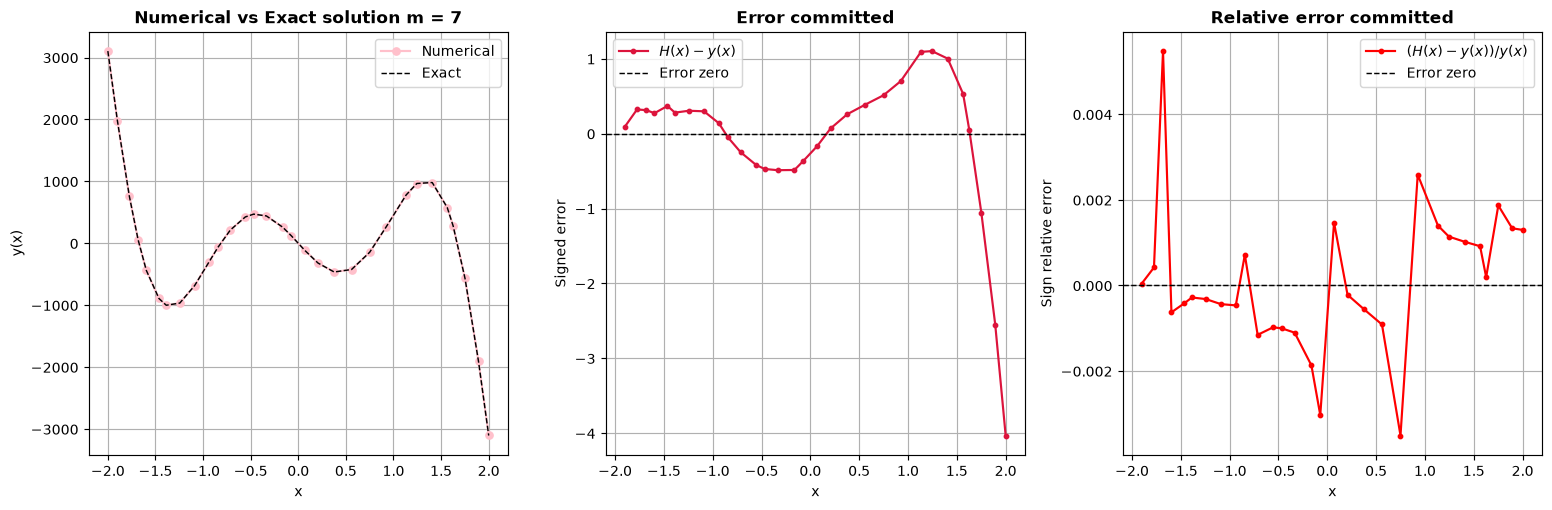

In [13]:
# Plotting results
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (15, 5))

ax1.plot(x, y, linestyle = 'solid', marker = 'o', label = 'Numerical', color = 'pink', markersize = 5)
ax1.plot(x, H(x), linestyle = 'dashed', label = 'Exact', color = 'black', linewidth = 1.0)
ax1.set_xlabel('x')
ax1.set_ylabel('y(x)')
ax1.set_title(f'Numerical vs Exact solution m = {m}', fontweight = 'bold')
ax1.legend(loc = 'best')
ax1.grid()

error = H(x) - y # Error with sign
ax2.plot(x[1:], error[1:], linestyle = 'solid', marker = 'o', color = 'crimson', label = r'$H(x) - y(x)$', markersize = 3)
ax2.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 1.0, label = 'Error zero')
ax2.set_xlabel('x')
ax2.set_ylabel('Signed error')
ax2.set_title('Error committed', fontweight = 'bold')
ax2.legend(loc = 'best')
ax2.grid()

rel_error = (H(x) - y) / y # Relative error
ax3.plot(x[1:], rel_error[1:], linestyle = 'solid', marker = 'o', color = 'red', label = r'$(H(x) - y(x)) / y(x)$', markersize = 3)
ax3.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 1.0, label = 'Error zero')
ax3.set_xlabel('x')
ax3.set_ylabel('Sign relative error')
ax3.set_title('Relative error committed', fontweight = 'bold')
ax3.legend(loc = 'best')
ax3.grid()

plt.tight_layout()
plt.show()

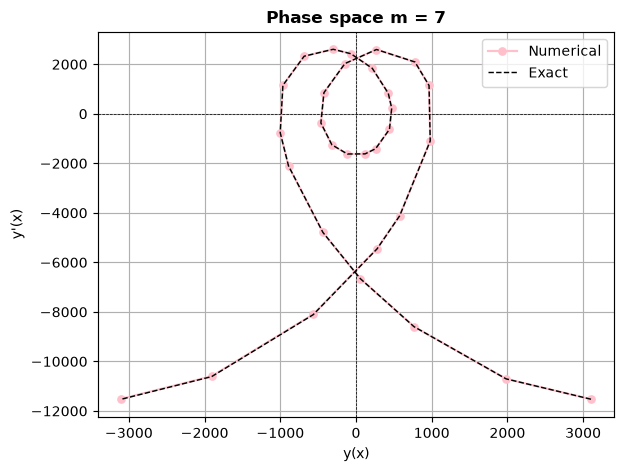

In [14]:
# Plotting phase space
plt.plot(y, v, linestyle = 'solid', marker = 'o', label = 'Numerical', color = 'pink', markersize = 5)
plt.plot(y, H.deriv()(x), linestyle = 'dashed', label = 'Exact', color = 'black', linewidth = 1.0)
plt.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 0.5)
plt.axvline(0, linestyle = 'dashed', color = 'black', linewidth = 0.5)
plt.xlabel('y(x)')
plt.ylabel("y'(x)")
plt.title(f'Phase space m = {m}', fontweight = 'bold')
plt.legend(loc = 'best')
plt.grid()
plt.show()

In [15]:
np.max(np.abs(H(x) - y)), np.max(np.abs((H(x) - y) / y)) # Maximum error committed, absolute and relative

(np.float64(4.0305952467333555), np.float64(0.005480074015387552))

Suppose we do not know the exact solution (typical scenario in real world). How could we estimate the global absolute error in this case? Let's try an interpolation method

In [16]:
x2, y2, _ = taylor45( # Solution low tolerances
    m = m,
    h0 = h0,
    x0 = x0,
    y0 = H(x0),
    v0 = H.deriv()(x0),
    X = X,
    atol = 1e-08,
    rtol = 1e-05,
    safety = 0.9,
    max_growth = 2.0
    )

In [17]:
Y = make_interp_spline( # Quadratic interpolation using more accurate solution
    x = x2,
    y = y2,
    k = 2
)

est_err = Y(x) - y # Estimated errors for y (not y2), with sign
est_err, error # Direct comparison with real error

(array([ 0.        ,  0.40243504,  0.32407527,  0.28908882,  0.24887373,
         0.35020967,  0.28319976,  0.25387444,  0.31600382,  0.20363845,
        -0.04860188, -0.24633415, -0.40590363, -0.45614864, -0.46530514,
        -0.51341389, -0.33761945, -0.17890179,  0.09910448,  0.2395417 ,
         0.37853943,  0.49178292,  0.77077385,  1.09570343,  1.06438453,
         1.03689995,  0.50817083,  0.06952666, -1.01018156, -2.63082474,
        -3.99657661]),
 array([ 0.        ,  0.0923008 ,  0.32269124,  0.31468879,  0.27379775,
         0.36954153,  0.28076647,  0.30594891,  0.2984121 ,  0.13986827,
        -0.04810358, -0.24828759, -0.41697192, -0.47163197, -0.48776298,
        -0.48502444, -0.36454888, -0.1681603 ,  0.06939408,  0.25883766,
         0.38583018,  0.5125991 ,  0.70175212,  1.09187759,  1.10247789,
         1.00191437,  0.53004876,  0.05452572, -1.05636467, -2.54830165,
        -4.03059525]))

In [18]:
for E, T in zip(np.abs(est_err[1:]), np.abs(error[1:])): # Actually, only the first significant value metters. Take absolute values
    print(f"{E:.1g} vs {T:.1g}")

0.4 vs 0.09
0.3 vs 0.3
0.3 vs 0.3
0.2 vs 0.3
0.4 vs 0.4
0.3 vs 0.3
0.3 vs 0.3
0.3 vs 0.3
0.2 vs 0.1
0.05 vs 0.05
0.2 vs 0.2
0.4 vs 0.4
0.5 vs 0.5
0.5 vs 0.5
0.5 vs 0.5
0.3 vs 0.4
0.2 vs 0.2
0.1 vs 0.07
0.2 vs 0.3
0.4 vs 0.4
0.5 vs 0.5
0.8 vs 0.7
1 vs 1
1 vs 1
1 vs 1
0.5 vs 0.5
0.07 vs 0.05
1 vs 1
3 vs 3
4 vs 4


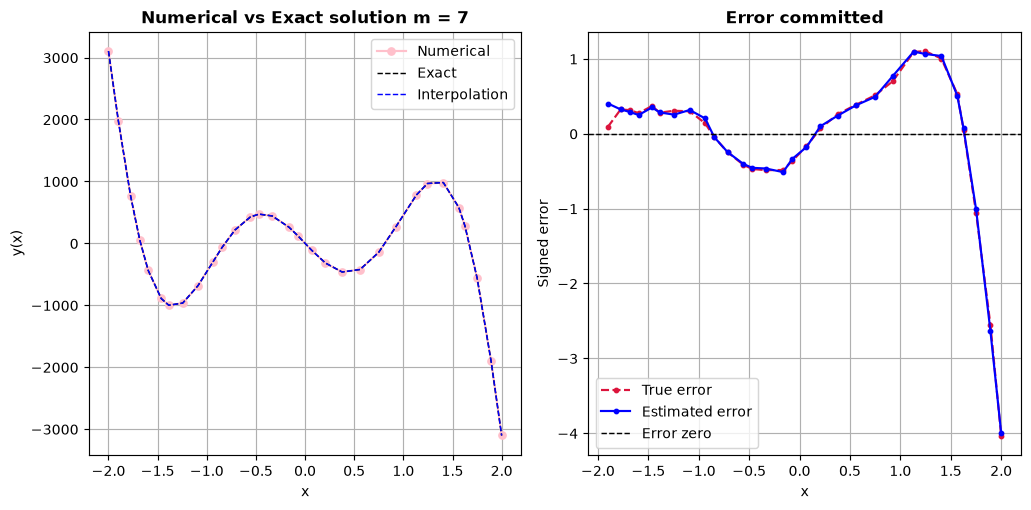

In [19]:
# Plotting results
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

ax1.plot(x, y, linestyle = 'solid', marker = 'o', label = 'Numerical', color = 'pink', markersize = 5)
ax1.plot(x, H(x), linestyle = 'dashed', label = 'Exact', color = 'black', linewidth = 1.0)
ax1.plot(x, Y(x), linestyle = 'dashed', label = 'Interpolation', color = 'blue', linewidth = 1.0)
ax1.set_xlabel('x')
ax1.set_ylabel('y(x)')
ax1.set_title(f'Numerical vs Exact solution m = {m}', fontweight = 'bold')
ax1.legend(loc = 'best')
ax1.grid()

ax2.plot(x[1:], error[1:], linestyle = 'dashed', marker = 'o', color = 'crimson', label = 'True error', markersize = 3)
ax2.plot(x[1:], est_err[1:], linestyle = 'solid', marker = 'o', color = 'blue', label = 'Estimated error', markersize = 3)
ax2.axhline(0, linestyle = 'dashed', color = 'black', linewidth = 1.0, label = 'Error zero')
ax2.set_xlabel('x')
ax2.set_ylabel('Signed error')
ax2.set_title('Error committed', fontweight = 'bold')
ax2.legend(loc = 'best')
ax2.grid()

plt.tight_layout()
plt.show()

The interpolation methods works very well